Анализ **датасета** для статпрака. Демо версия. Выполняют Кротов Владимир и Ласкин Михаил

*Введение, цели и задачи*, да и вообще *оформление* будет чуть позже. Пока накидал идей и графиков, что мы в целом рассмотрим. Планируем выступить **12 мая**

## Анализ данных абитуриентов Мехмата МГУ
Проанализируем данные приёмной кампании мехмата МГУ по общему конкурсу. 
Посмотрим на сами данные:

In [1]:
import numpy as np
import pandas as pd

In [2]:
entrants = pd.read_csv("math_entrants.csv")
entrants.head()

,№,Наличие согласия,Согласие в МГУ,Сумма баллов,Математика (ДВИ),Математика (ЕГЭ),Физика,Русский язык,Индивидуальные достижения - аттестат,Индивидуальные достижения - сочинение,Индивидуальные достижения - ГТО,Преимущественное право зачисления,Право на общежитие,Статус
0,1,Да,Да,408,100,100,100,100,6,2,0,Нет,Нет,В конкурсе
1,2,Нет,Нет,408,100,100,100,100,6,2,0,Нет,Нет,В конкурсе
2,3,Нет,Нет,408,100,100,100,100,6,2,0,Нет,Да,В конкурсе
3,4,Нет,Да,408,100,100,100,100,6,2,0,Нет,Нет,В конкурсе
4,5,Нет,Нет,407,100,99,100,100,6,2,0,Нет,Да,В конкурсе


In [3]:
entrants.columns

Index(['№', 'Наличие согласия', 'Согласие в МГУ', 'Сумма баллов',
       'Математика (ДВИ)', 'Математика (ЕГЭ)', 'Физика', 'Русский язык',
       'Индивидуальные достижения - аттестат',
       'Индивидуальные достижения - сочинение',
       'Индивидуальные достижения - ГТО', 'Преимущественное право зачисления',
       'Право на общежитие', 'Статус'],
      dtype='object')

Для простоты работы со столбцами переименуем их так, чтобы с ними было легче работать. Не будем отказываться полностью от русского языка, но сократим название каждого столбца до одного слова.

In [4]:
entrants.rename(columns = {'Сумма баллов':'сумма',
                           'Математика (ДВИ)':'ДВИ',
                           'Математика (ЕГЭ)':'математика',
                           'Физика':'физика',
                           'Русский язык':'русский',
                           'Индивидуальные достижения - аттестат':'аттестат',
                           'Индивидуальные достижения - сочинение':'сочинение',
                           'Индивидуальные достижения - ГТО':'ГТО',
                           'Преимущественное право зачисления':'преимущество',
                           'Право на общежитие':'общежитие'},
                inplace=True)
entrants.head()

,№,Наличие согласия,Согласие в МГУ,сумма,ДВИ,математика,физика,русский,аттестат,сочинение,ГТО,преимущество,общежитие,Статус
0,1,Да,Да,408,100,100,100,100,6,2,0,Нет,Нет,В конкурсе
1,2,Нет,Нет,408,100,100,100,100,6,2,0,Нет,Нет,В конкурсе
2,3,Нет,Нет,408,100,100,100,100,6,2,0,Нет,Да,В конкурсе
3,4,Нет,Да,408,100,100,100,100,6,2,0,Нет,Нет,В конкурсе
4,5,Нет,Нет,407,100,99,100,100,6,2,0,Нет,Да,В конкурсе


Всегда удобнее работать с типом данных bool, чем с типом данных string. Изменим тип данных в столбцах типа "Да/Нет" на логический:

In [5]:
entrants["Наличие согласия"] = (entrants["Наличие согласия"] == "Да")
entrants["Согласие в МГУ"] = (entrants["Согласие в МГУ"] == "Да")
entrants["преимущество"] = (entrants["преимущество"] == "Да")
entrants["общежитие"] = (entrants["общежитие"] == "Да")
entrants.head()

,№,Наличие согласия,Согласие в МГУ,сумма,ДВИ,математика,физика,русский,аттестат,сочинение,ГТО,преимущество,общежитие,Статус
0,1,True,True,408,100,100,100,100,6,2,0,False,False,В конкурсе
1,2,False,False,408,100,100,100,100,6,2,0,False,False,В конкурсе
2,3,False,False,408,100,100,100,100,6,2,0,False,True,В конкурсе
3,4,False,True,408,100,100,100,100,6,2,0,False,False,В конкурсе
4,5,False,False,407,100,99,100,100,6,2,0,False,True,В конкурсе


In [6]:
entrants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 905 entries, 0 to 904
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   №                 905 non-null    int64 
 1   Наличие согласия  905 non-null    bool  
 2   Согласие в МГУ    905 non-null    bool  
 3   сумма             905 non-null    int64 
 4   ДВИ               905 non-null    int64 
 5   математика        905 non-null    int64 
 6   физика            905 non-null    int64 
 7   русский           905 non-null    int64 
 8   аттестат          905 non-null    int64 
 9   сочинение         905 non-null    int64 
 10  ГТО               905 non-null    int64 
 11  преимущество      905 non-null    bool  
 12  общежитие         905 non-null    bool  
 13  Статус            905 non-null    object
dtypes: bool(4), int64(9), object(1)
memory usage: 74.4+ KB


Проверим, не у всех ли студентов из данного списка статус "В конкурсе". Если это так, то данный столбец ничем не поможет нам в анализе данных, и мы сможем его удалить

In [7]:
(entrants['Статус'] == 'В конкурсе').all()

np.True_

У всех. Значит, этот столбец можно просто удалить:

In [8]:
entrants.drop('Статус', axis=1, inplace=True)

Проверим то же самое про преимущество:

In [9]:
entrants["преимущество"].value_counts()

преимущество
False    905
Name: count, dtype: int64

In [10]:
entrants["ГТО"].value_counts()

ГТО
0    746
2    159
Name: count, dtype: int64

In [11]:
entrants['преимущество'].any()

np.False_

Значит, от него также можно избавиться

In [12]:
entrants.drop('преимущество', axis=1, inplace=True)

Оценим общее описание всех параметров данных

In [13]:
entrants.describe()

,№,сумма,ДВИ,математика,физика,русский,аттестат,сочинение,ГТО
count,905.000000,905.000000,905.000000,905.000000,905.000000,905.000000,905.000000,905.000000,905.000000
mean,453.000000,351.367956,77.662983,89.240884,89.038674,90.453039,2.671823,1.949171,0.351381
std,261.395295,27.547675,15.383455,7.546133,9.649823,6.576663,2.983645,0.314934,0.761534
min,1.000000,268.000000,50.000000,62.000000,55.000000,60.000000,0.000000,0.000000,0.000000
25%,227.000000,332.000000,65.000000,84.000000,84.000000,86.000000,0.000000,2.000000,0.000000
50%,453.000000,354.000000,80.000000,90.000000,91.000000,92.000000,0.000000,2.000000,0.000000
75%,679.000000,371.000000,90.000000,96.000000,97.000000,96.000000,6.000000,2.000000,0.000000
max,905.000000,408.000000,100.000000,100.000000,100.000000,100.000000,6.000000,2.000000,2.000000


In [14]:
entrants

,№,Наличие согласия,Согласие в МГУ,сумма,ДВИ,математика,физика,русский,аттестат,сочинение,ГТО,общежитие
0,1,True,True,408,100,100,100,100,6,2,0,False
1,2,False,False,408,100,100,100,100,6,2,0,False
2,3,False,False,408,100,100,100,100,6,2,0,True
3,4,False,True,408,100,100,100,100,6,2,0,False
4,5,False,False,407,100,99,100,100,6,2,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
900,901,False,True,277,55,72,64,78,6,2,0,True
901,902,False,False,275,50,78,57,80,6,2,2,True
902,903,False,True,272,60,70,60,80,0,2,0,False
903,904,False,True,270,70,70,57,69,0,2,2,False



Первое, что стоит сделать — посмотреть, как выглядит распределение суммы баллов на гистограмме. Мы увидим, какую структуру имеют данные.

<Axes: >

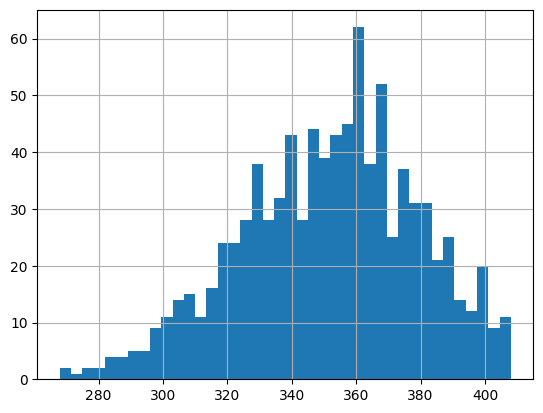

In [15]:
entrants['сумма'].hist(bins=40)

Проверим, такое же распределение получается у студентов, сдавших успешно ГТО? Может быть, ГТО существенно повлияло на их поступление, хотя они менее или более талантливы, чем другие студенты?

352.61006289308176


<Axes: ylabel='Frequency'>

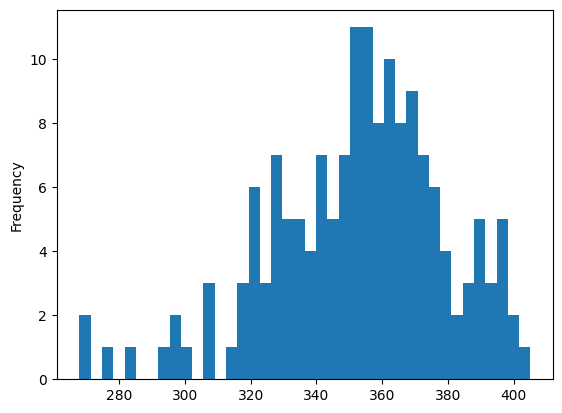

In [16]:
print(entrants.query('ГТО == 2')['сумма'].mean())
entrants.query('ГТО == 2')['сумма'].plot.hist(bins=40)

Как мы видим, распределение очень похоже, имеет тот же максимум. Значит, наша гипотеза неверна. А что насчет несдавших ГТО?

351.10321715817696


<Axes: ylabel='Frequency'>

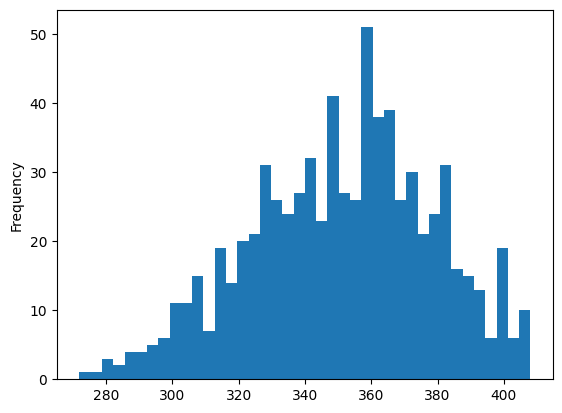

In [17]:
print(entrants.query('ГТО == 0')['сумма'].mean())
entrants.query('ГТО == 0')['сумма'].plot.hist(bins=40)

In [ ]:
Посмотрим на сто балльников по ДВИ математике

<Axes: ylabel='Frequency'>

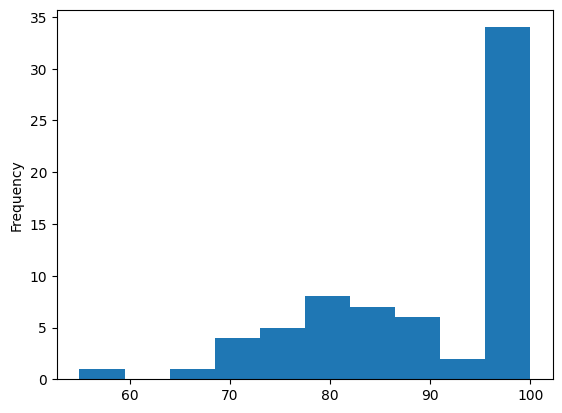

In [18]:
entrants.query("`математика` == 100")["ДВИ"].plot.hist(bins=10)

Выдвинем следующую гипотезу:
студенты, успешно сдавшие ЕГЭ по математике, должны были хорошо сдать и ДВИ. Если это так и если мы отметим всех студентов в координатах "Балл за ДВИ" - "Балл за ЕГЭ по математике", мы должны увидеть скопление в области высоких баллов по обеим осям. Изобразим такой поточечный график:

<Axes: xlabel='ДВИ', ylabel='математика'>

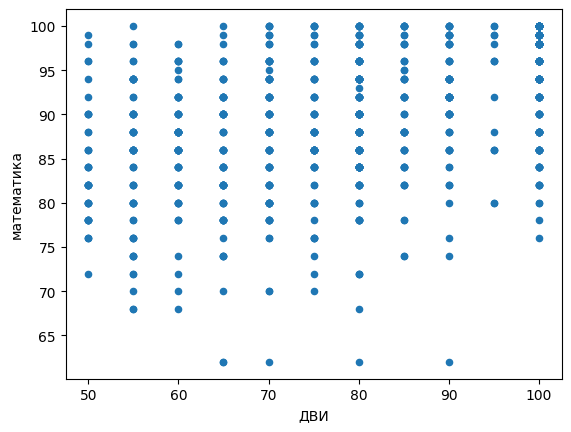

In [19]:
entrants.plot.scatter("ДВИ", "математика")

Кажется, что распределение баллов по математике при каждом фиксированном балле за ДВИ почти равномерное в области "Балл за математику > 75". Но так ли это в действительности? Может быть, все дело в особенности отображения поточечного графика?

Нарисуем другой тип графика, так называемые "свечи":

<Axes: >

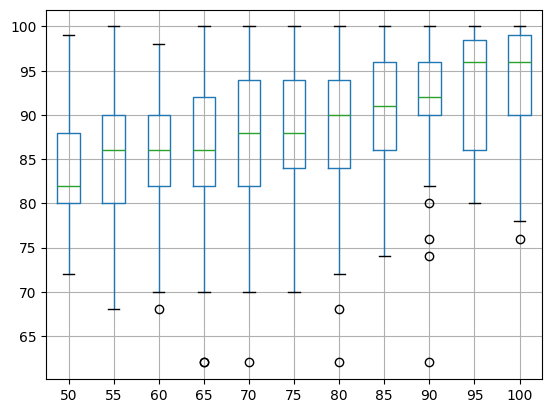

In [20]:
entrants.pivot_table(index='№', columns='ДВИ', values='математика').boxplot()

Мы действительно наблюдаем смещение медианного значения балла ЕГЭ по математике ближе к 100 при увеличении баллов за ДВИ. Это подтверждает нашу гипотезу. Проверим это, применив усреднение:

In [21]:
entrants.pivot_table(index='ДВИ', values='математика', aggfunc='mean')

,математика
ДВИ,
50,84.073171
55,85.217391
60,86.408451
65,85.467532
70,87.857143
75,88.162162
80,89.401361
85,90.433333
90,91.817073


<Axes: xlabel='ДВИ'>

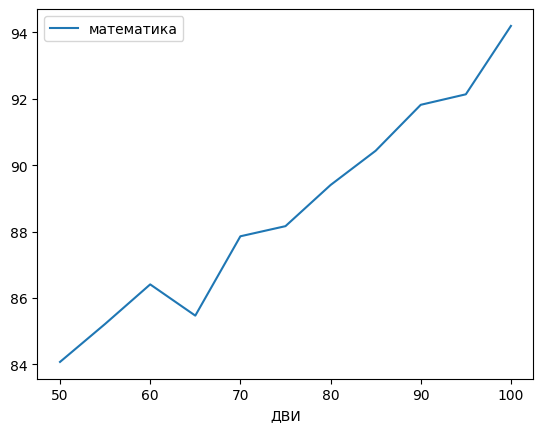

In [22]:
entrants.pivot_table(index='ДВИ', values='математика', aggfunc='mean').plot()

Есть ли подобные корелляции в случае с парой "Физика"/"Математика"?

<Axes: xlabel='физика', ylabel='математика'>

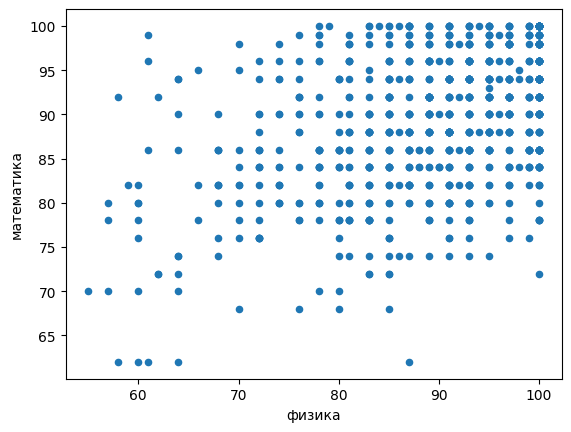

In [23]:
entrants.plot.scatter("физика", "математика")

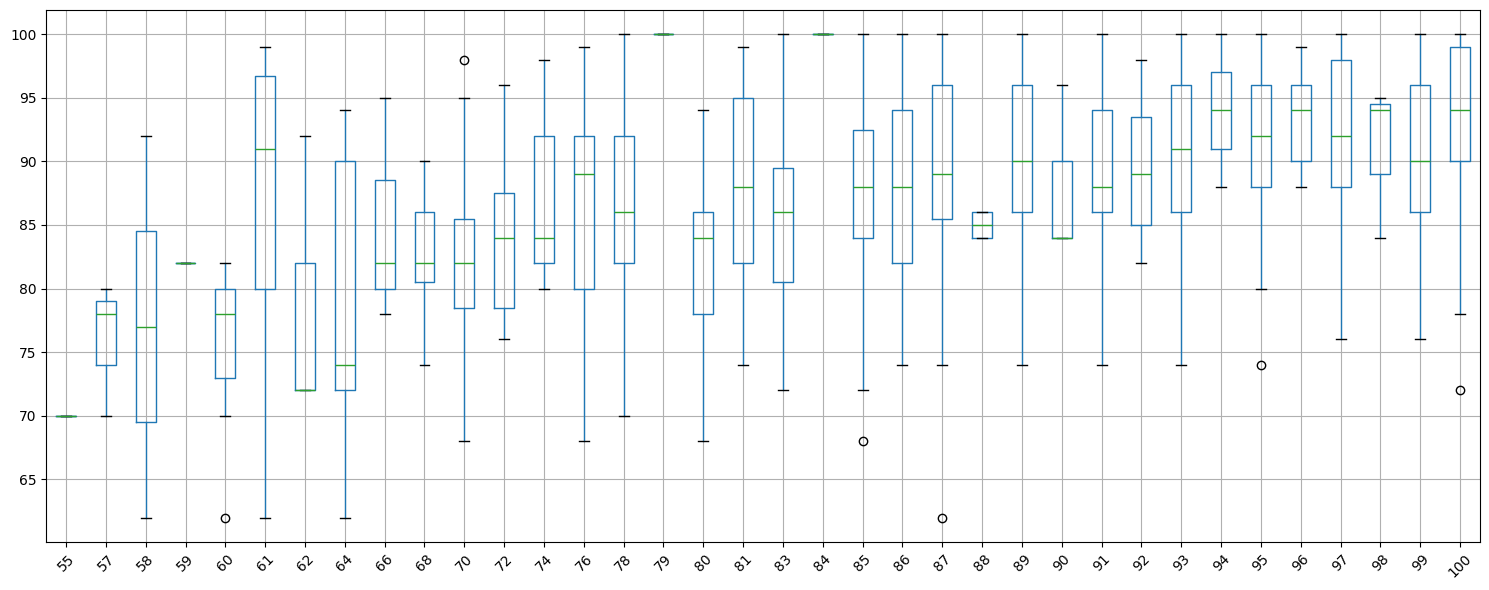

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))  
entrants.pivot_table(index='№', columns='физика', values='математика').boxplot()
plt.xticks(rotation=45)  
plt.tight_layout()  
plt.show()

Здесь корреляция видна невооруженным глазом. Протестируем другие пары предметов:

<Axes: xlabel='математика', ylabel='русский'>

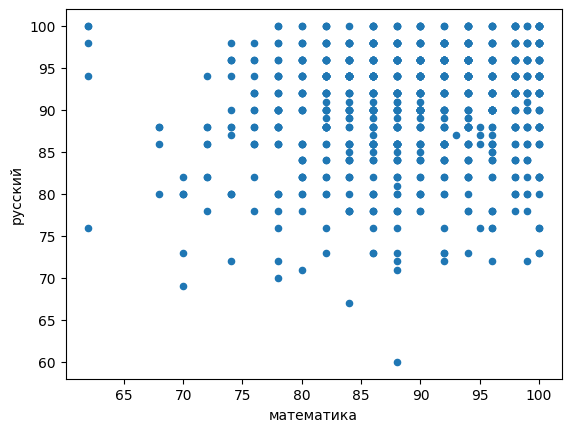

In [25]:
entrants.plot.scatter("математика", "русский")

<Axes: >

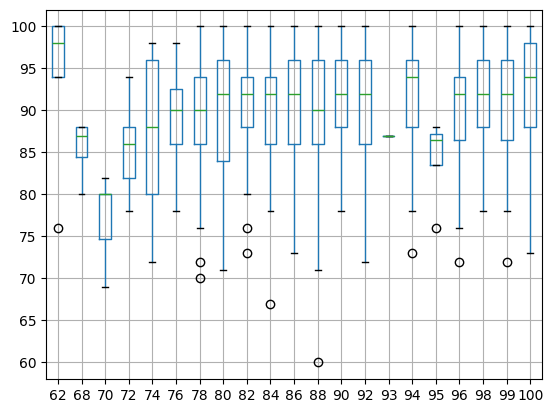

In [26]:
entrants.pivot_table(index='№', columns='математика', values='русский').boxplot()

С русским языком такой корелляции не прослеживается. Это объяснимо: знание физики и математики связано друг с другом, как и способность студента одновременно хорошо сдать математику ДВИ и математику ЕГЭ. С русским языком же такой зависимости не наблюдается.